# Phase 1: EDA & Statistical Analysis
**Dataset:** Kinsei Sangyo — Industrial Waste Incineration Images
**Format:** COCO Segmentation

## 1. Imports & Setup

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy import stats

sns.set_theme(style='whitegrid')
print('All imports successful')

All imports successful


## 2. Dataset Overview

In [2]:
# Define dataset paths
DATASET_PATH = '../data/raw'
TRAIN_JSON = os.path.join(DATASET_PATH, 'train/_annotations.coco.json')
VAL_JSON   = os.path.join(DATASET_PATH, 'valid/_annotations.coco.json')
TEST_JSON  = os.path.join(DATASET_PATH, 'test/_annotations.coco.json')

# Load annotations
with open(TRAIN_JSON) as f:
    train_data = json.load(f)
with open(VAL_JSON) as f:
    val_data = json.load(f)
with open(TEST_JSON) as f:
    test_data = json.load(f)

print('Train images :', len(train_data['images']))
print('Valid images :', len(val_data['images']))
print('Test  images :', len(test_data['images']))
print('Total        :', len(train_data['images']) + len(val_data['images']) + len(test_data['images']))
print('Classes      :', [c['name'] for c in train_data['categories']])

Train images : 1008
Valid images : 96
Test  images : 49
Total        : 1153
Classes      : ['wastes', 'Metal', 'Mixed Waste', 'Paper-Cardboard', 'Plastic', 'Wood']


## 3. Class Distribution

Annotation count per class:
class_name
Plastic            7511
Paper-Cardboard    6254
Mixed Waste        2262
Metal              1227
Wood                767
Name: count, dtype: int64


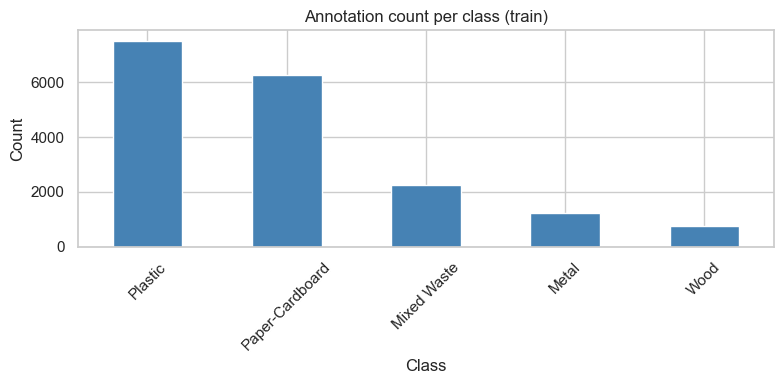

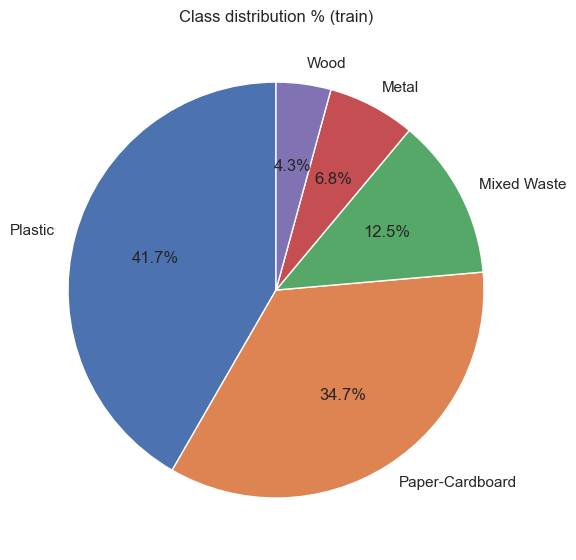

In [3]:
# Build annotation dataframe
cat_map = {c['id']: c['name'] for c in train_data['categories']}
df = pd.DataFrame(train_data['annotations'])
df['class_name'] = df['category_id'].map(cat_map)
df['bbox_area']  = df['bbox'].apply(lambda b: b[2] * b[3])

print('Annotation count per class:')
print(df['class_name'].value_counts())

# Bar chart
plt.figure(figsize=(8, 4))
df['class_name'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Annotation count per class (train)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie chart
total_ann = len(df)
class_pct = (df['class_name'].value_counts() / total_ann * 100).round(2)
plt.figure(figsize=(6, 6))
class_pct.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Class distribution % (train)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Image Quality Analysis

In [ ]:
# Image size distribution
widths  = [img['width']  for img in train_data['images']]
heights = [img['height'] for img in train_data['images']]

print(f'Width  — min: {min(widths)}  max: {max(widths)}  mean: {round(np.mean(widths))}')
print(f'Height — min: {min(heights)} max: {max(heights)} mean: {round(np.mean(heights))}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image width distribution')
axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Image height distribution')
plt.tight_layout()
plt.show()

# Annotations per image
img_ann_count = Counter(ann['image_id'] for ann in train_data['annotations'])
ann_counts    = list(img_ann_count.values())

print(f'\nAvg annotations per image: {np.mean(ann_counts):.2f}')
print(f'Max annotations per image: {max(ann_counts)}')
print(f'Min annotations per image: {min(ann_counts)}')

plt.figure(figsize=(8, 4))
plt.hist(ann_counts, bins=20, color='steelblue', edgecolor='white')
plt.title('Number of annotations per image (train)')
plt.xlabel('Annotation count')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

# Bounding box area per class
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='class_name', y='bbox_area', palette='Set2')
plt.title('Bounding box area distribution per class')
plt.xlabel('Class')
plt.ylabel('Area (pixels²)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Unannotated images
annotated_ids   = set(df['image_id'].unique())
all_ids         = set(img['id'] for img in train_data['images'])
unannotated_ids = all_ids - annotated_ids
print(f'\nAnnotated images : {len(annotated_ids)}')
print(f'Unannotated      : {len(unannotated_ids)}')

## 5. Correlation Analysis

In [ ]:
# Correlation between waste classes per image
img_class_counts = df.groupby(['image_id', 'class_name']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(img_class_counts.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between waste classes per image')
plt.tight_layout()
plt.show()

print('Correlation matrix:')
print(img_class_counts.corr().round(2))

## 6. Outlier Detection

In [ ]:
# IQR method — outlier images by annotation count
ann_series = pd.Series(ann_counts)
Q1, Q3     = ann_series.quantile(0.25), ann_series.quantile(0.75)
IQR        = Q3 - Q1
outliers   = ann_series[(ann_series < Q1 - 1.5 * IQR) | (ann_series > Q3 + 1.5 * IQR)]

print(f'Q1: {Q1},  Q3: {Q3},  IQR: {IQR}')
print(f'Outlier images (by annotation count): {len(outliers)}')
print(outliers.sort_values(ascending=False).head(10))

# Outlier by bbox area per class
for cls in df['class_name'].unique():
    subset = df[df['class_name'] == cls]['bbox_area']
    q1, q3 = subset.quantile(0.25), subset.quantile(0.75)
    iqr    = q3 - q1
    out    = subset[(subset < q1 - 1.5 * iqr) | (subset > q3 + 1.5 * iqr)]
    print(f'{cls}: {len(out)} outlier annotations')

## 7. Statistical Hypothesis Testing

In [ ]:
# Test: does bbox area differ significantly between classes?
# Using Kruskal-Wallis (non-parametric, no normality assumption)
groups = [df[df['class_name'] == cls]['bbox_area'].values
          for cls in df['class_name'].unique()]

stat, p_value = stats.kruskal(*groups)
print(f'Kruskal-Wallis test — H-stat: {stat:.4f},  p-value: {p_value:.6f}')

if p_value < 0.05:
    print('Result: Significant difference in bbox area across classes (p < 0.05)')
else:
    print('Result: No significant difference found (p >= 0.05)')

# Summary stats per class
summary = df.groupby('class_name')['bbox_area'].describe()
print('\nSummary statistics of bounding box area per class:')
print(summary)

## 8. Business Insights

Fill in findings after running all cells above.

**Template:**
- **Dominant class:** `___` accounts for `__`% of all annotations
- **Co-occurrence:** classes `___` and `___` tend to appear together (correlation = `__`)
- **Outlier batches:** `__` images have unusually high annotation counts — worth investigating
- **Size variation:** class `___` shows highest bbox area variance — may affect segmentation accuracy
- **Operational recommendation:** `___`